# `strain_tools` examples

We will calculate strain rates at Store Glacier (Sermeq Kujalleq), an outlet glacier of the West Greenland Ice Sheet.

The velocity data is from ITS_LIVE multi-annual velocity mosaic:

> Gardner _et al._ (2025). ITS_LIVE Regional Glacier and Ice Sheet Surface Velocities: Version 2. Data archived at National Snow and Ice Data Center; https://doi:10.5067/6II6VW8LLWJ7.

The mask is the PROMICE-2022 ice mask:

> Luetzenburg _et al._ (2025). PROMICE-2022 Ice Mask V2. Data archived at the GEUS Dataverse. https://doi.org/10.22008/FK2/O8CLRE.

## Housekeeping

Load modules.

In [1]:
import rioxarray as rxr 
import matplotlib.pyplot as plt 
import geopandas as gpd
import numpy as np

import strain_tools as st 

Set display options for `matplotlib`.

In [2]:

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Load and clean velocity fields

We will loads the ITS_LIVE multi-annual velocity mosaics for Store Glacier (Sermeq Kujalleq) in Greenland. We will use `rioxarray` to load and manipulate the data. `strain_tools` will also accept `numpy.ndarray`s however, and will return the same data type as it is given.

In [3]:

# vv = rxr.open_rasterio('data/vv_store.tif').squeeze()
vx = rxr.open_rasterio('data/vx_store.tif').squeeze()
vy = rxr.open_rasterio('data/vy_store.tif').squeeze()
mask = rxr.open_rasterio('data/mask_store.tif').squeeze()

# vv = vv.where(mask==1, np.nan)
vx = vx.where(mask==1, np.nan)
vy = vy.where(mask==1, np.nan)

# Calculate absolute velocity
vv = np.sqrt(vx**2 + vy**2)


We can plot the velocity field using the `xarray` `.plot.imshow()` function, or using the slightly fancier option of `matplotlib`'s `streamplot`. 

> Note that `streamplot` currently has an issue where it is expecting `y` coordinates to be in the opposite direction to geographic y coordinates: note there is a handy utility in this toolkit (`st.flip()`) that can resolve this before feeding the data into `streamplot()`.

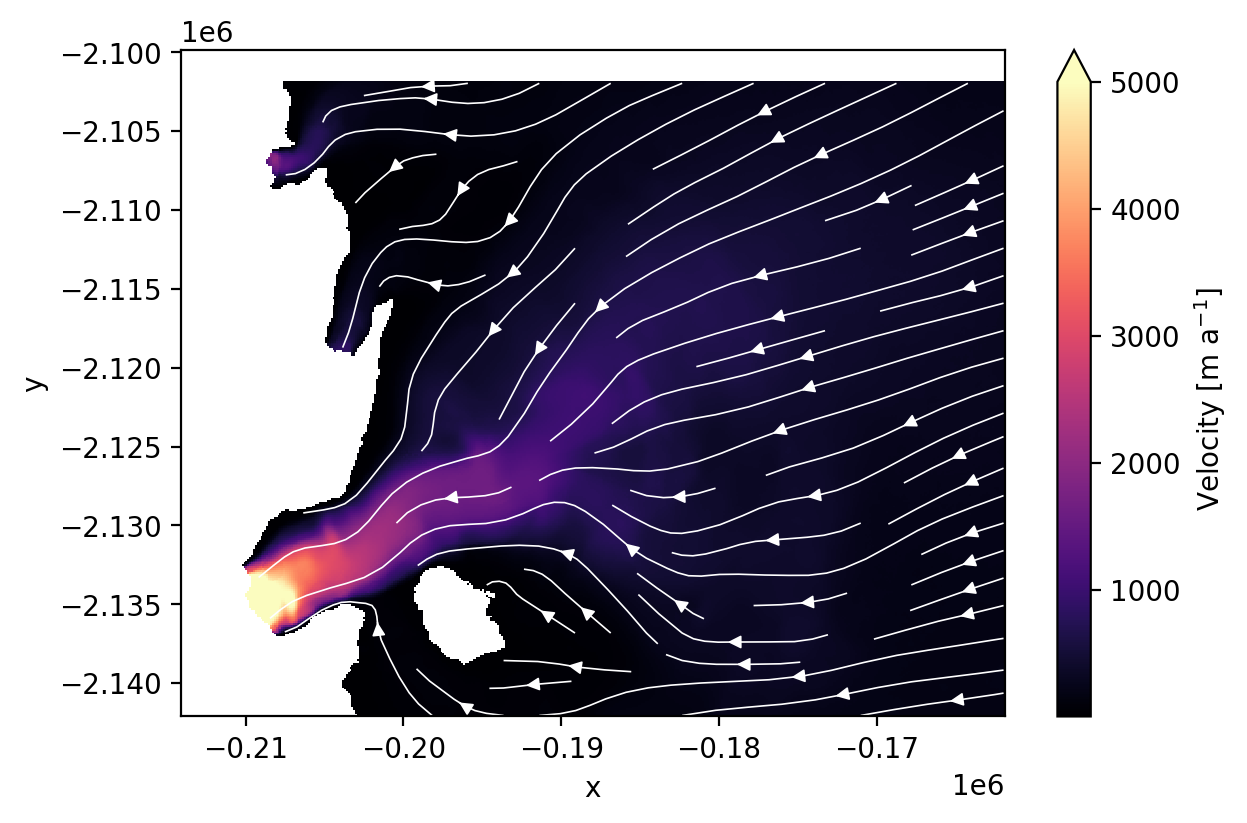

In [4]:
plt.close()
fig, ax = plt.subplots(layout='constrained', figsize=(6.5, 4))

# Plot velocity field colourmap
vv.plot.imshow(ax=ax, cmap="magma", vmax=5000, cbar_kwargs={'label':'Velocity [m a$^{-1}$]'})


# # Plot flow direction using streamplot
plt.streamplot(
    st.flip(vx).x.values, 
    st.flip(vx).y.values, 
    st.flip(vx).values, 
    st.flip(vy).values,
    color='white',
    linewidth=0.6,
    density=0.8,
)

ax.ticklabel_format(scilimits=(6,6))
ax.set_title(None)
ax.set_aspect('equal')

## Strain Rates

### Calculate Logarithmic Strain Rates

Now, we can calculate logarithmic strain rates following Alley _et al._ (2018; https://doi.org/10.1017/jog.2018.23) using the `strain.logarithmic()` function. 

This requires us to manually set the `pixel_size` (i.e. resolution) and `length_scale` ($r$ value in Alley _et al._) values. `unit_time` is non-mandatory but good to set, as this will allow the units to be carried through the entire workflow.

In [5]:
resolution = vv.rio.resolution()[0] # 120 metres
length_scale = 500 # metres

strain = st.strain.logarithmic(vx, vy, pixel_size=resolution, length_scale=length_scale, unit_time='a')

There are also two additional default variables, which I have not shown here. The first is the `tol` variable (tolerance for the addaptive time-stepping scheme, from Alley _et al._ 2018). This default should be adequate for most applications. The second is the `ydir` variable, set to 1 when the positive y direction is upscreen, and -1 when the positive y direction is downscreen. Here, it is 1. When xarray DataArrays are used, this is double-checked and a warning is raised if it could be wrong.

The output is an `xarray.DataSet` containing $\dot{\epsilon}_{xx}$, $\dot{\epsilon}_{yy}$, and $\dot{\epsilon}_{xy}$ values. If you instead feed a `numpy.ndarray`, the output will be a Tuple of three numpy arrays containing the same information.

In [6]:
strain

<xarray.Dataset> Size: 4MB
Dimensions:      (x: 435, y: 335)
Coordinates:
  * x            (x) float64 3kB -2.14e+05 -2.139e+05 ... -1.621e+05 -1.619e+05
  * y            (y) float64 3kB -2.102e+06 -2.102e+06 ... -2.142e+06 -2.142e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    e_xx         (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_yy         (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_xy         (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan

Once again, we can plot this information:

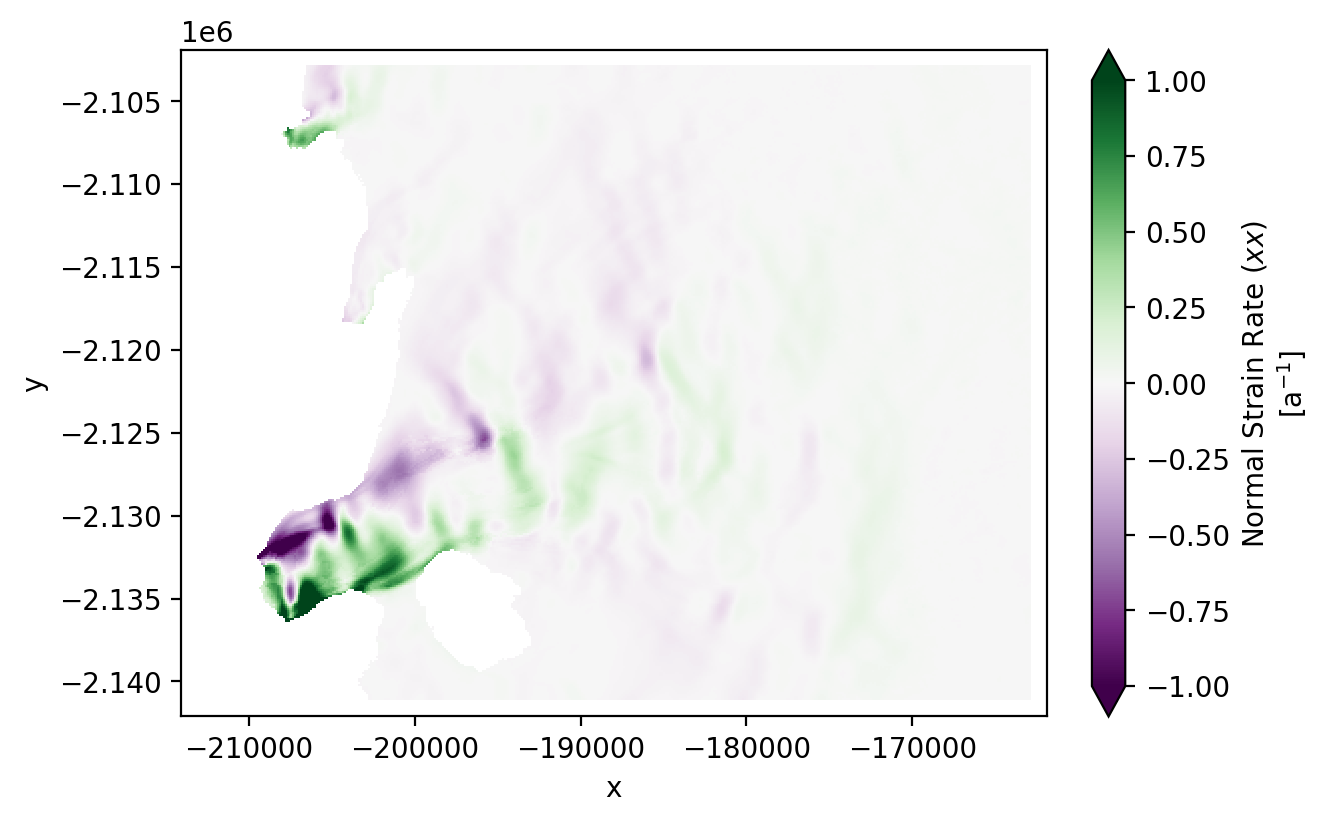

In [7]:
plt.close()
fig, ax = plt.subplots(layout='constrained', figsize=(6.5, 4))

vrange = 1.0 # a^-1

strain.e_xx.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax.set_aspect('equal')
ax.set_title(None)

plt.show()

### An Alternative: Nominal Strain Rates

You may be less familiar with logarithmic strain rates. A simpler, but more common method, of calculating strain rates is by calculating the _nominal_ strain rate from the finite difference of the velocity field (e.g. via `numpy.diff()`). The `strain.nominal()` function has you covered here, requiring `pixel_size` to function:

In [8]:
strain_nominal = st.strain.nominal(vx, vy, pixel_size=120, unit_time='a')

Note that this effectively calculates strain rates over a 3 $\times$ 3 pixel grid, which can be problematic for noisy datasets, and also means that the strain rate is dependent on your pixel size, rather than any independent ability to set your length scale of interest (e.g. via `length_scale` in the logarithmic approach).

See below as to how this impacts the data quality. For the rest of this notebook, we will be using the logarithmic strain rates. However, if you are processing very large velocity datasets, this method does have the benefit of being quicker to calculate.

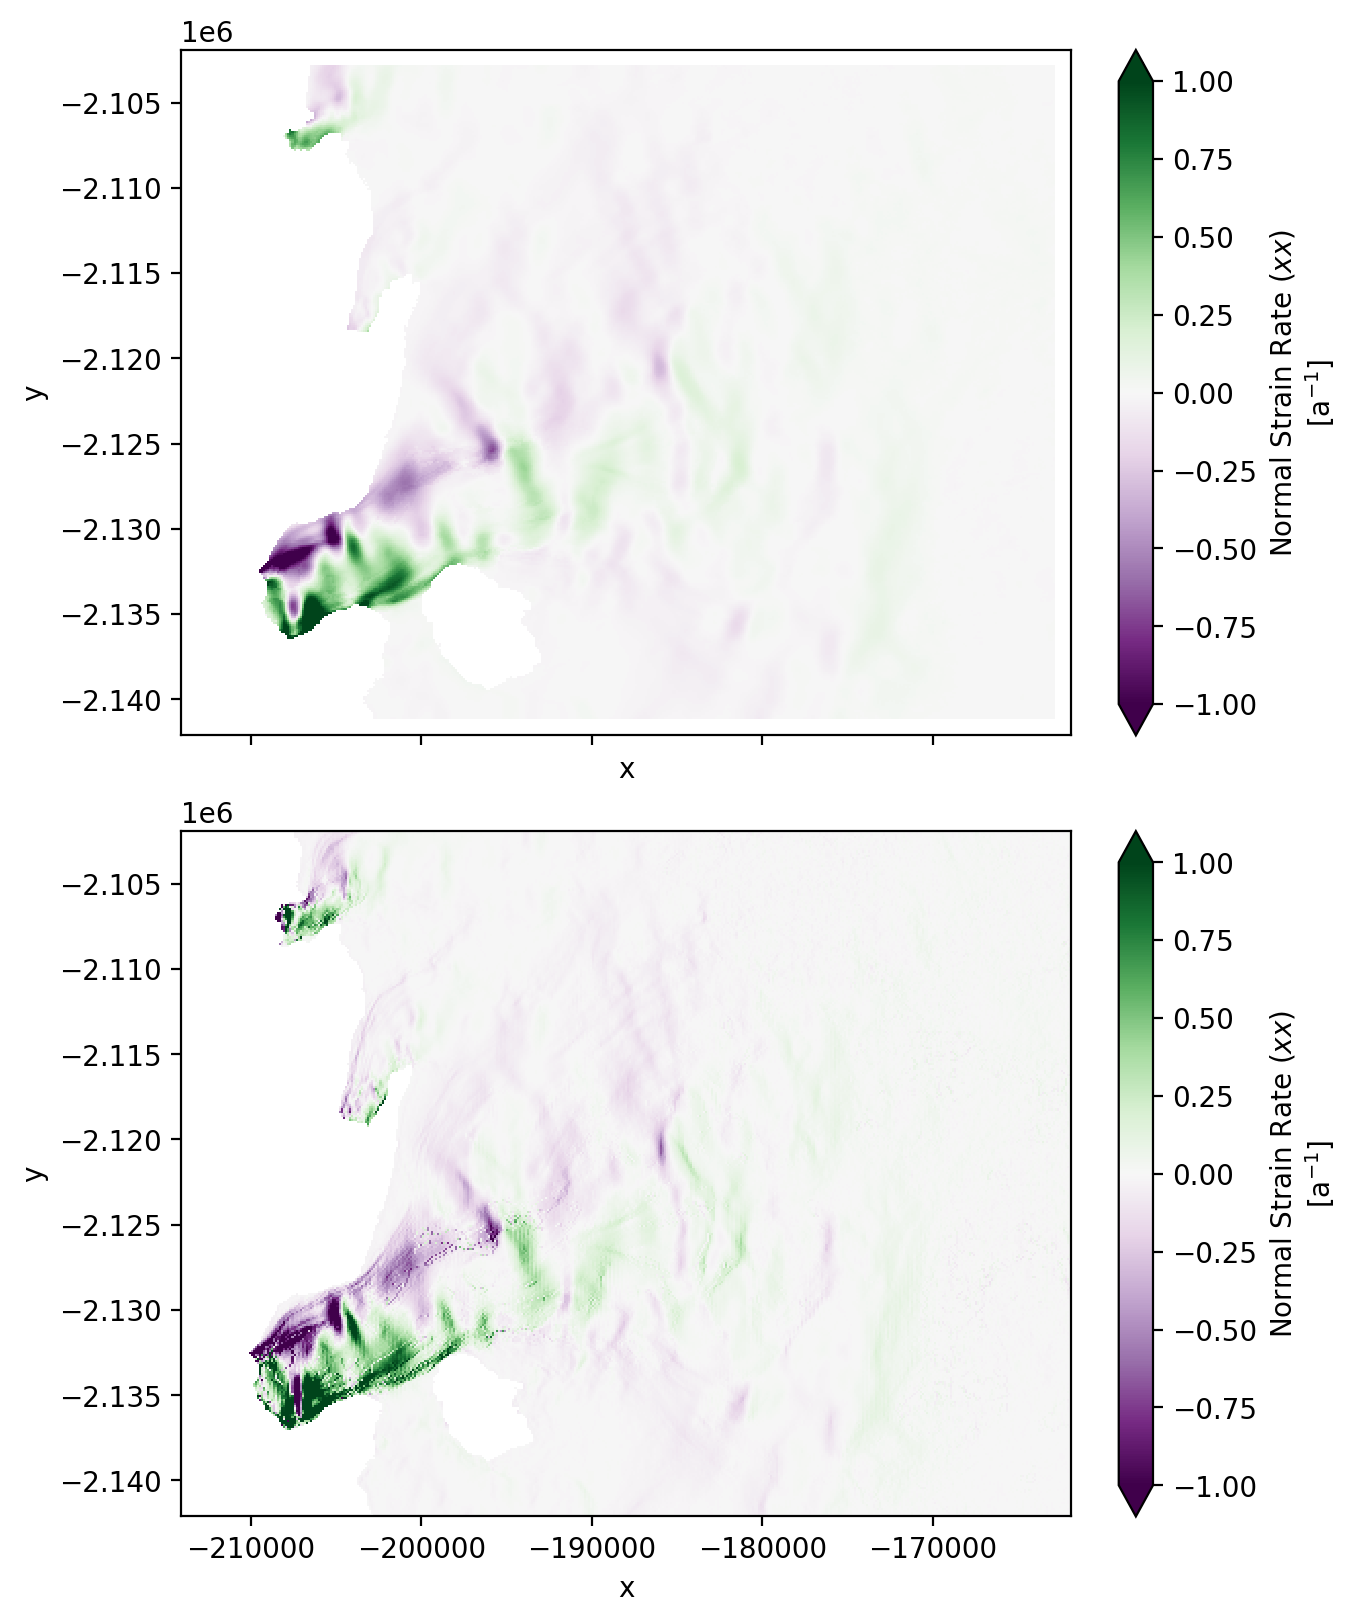

In [9]:
plt.close()
fig, axes = plt.subplots(nrows=2,sharex=True, sharey=True, layout='constrained', figsize=(6.5, 8))

vrange = 1.0 # a^-1

ax = axes[0]
strain.e_xx.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax = axes[1]
strain_nominal.e_xx.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

for ax in axes:
    ax.set_aspect('equal')
    ax.set_title(None)

plt.show()

### Principal Strain Rates

Principal strain rates are calculated as the eigenvectors of the normal strain rates. 

In [10]:
principal = st.strain.principal(strain.e_xx, strain.e_yy, strain.e_xy)

The default option calculates not only the magnitudes of the principal strain rates (`e_1` and `e_2`) but also the vector components (`e_1U`, `e_1V`, `e_2U`, `e_2V`). However, you can calculate just the magnitudes using a quicker method (following Nye, 1959) by setting `output='magnitudes'` (this is set to `directions` by default).

In [11]:
principal

<xarray.Dataset> Size: 7MB
Dimensions:      (x: 435, y: 335)
Coordinates:
  * x            (x) float64 3kB -2.14e+05 -2.139e+05 ... -1.621e+05 -1.619e+05
  * y            (y) float64 3kB -2.102e+06 -2.102e+06 ... -2.142e+06 -2.142e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    e_1          (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_1U         (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_1V         (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_2          (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_2U         (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_2V         (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan

Let's plot these:

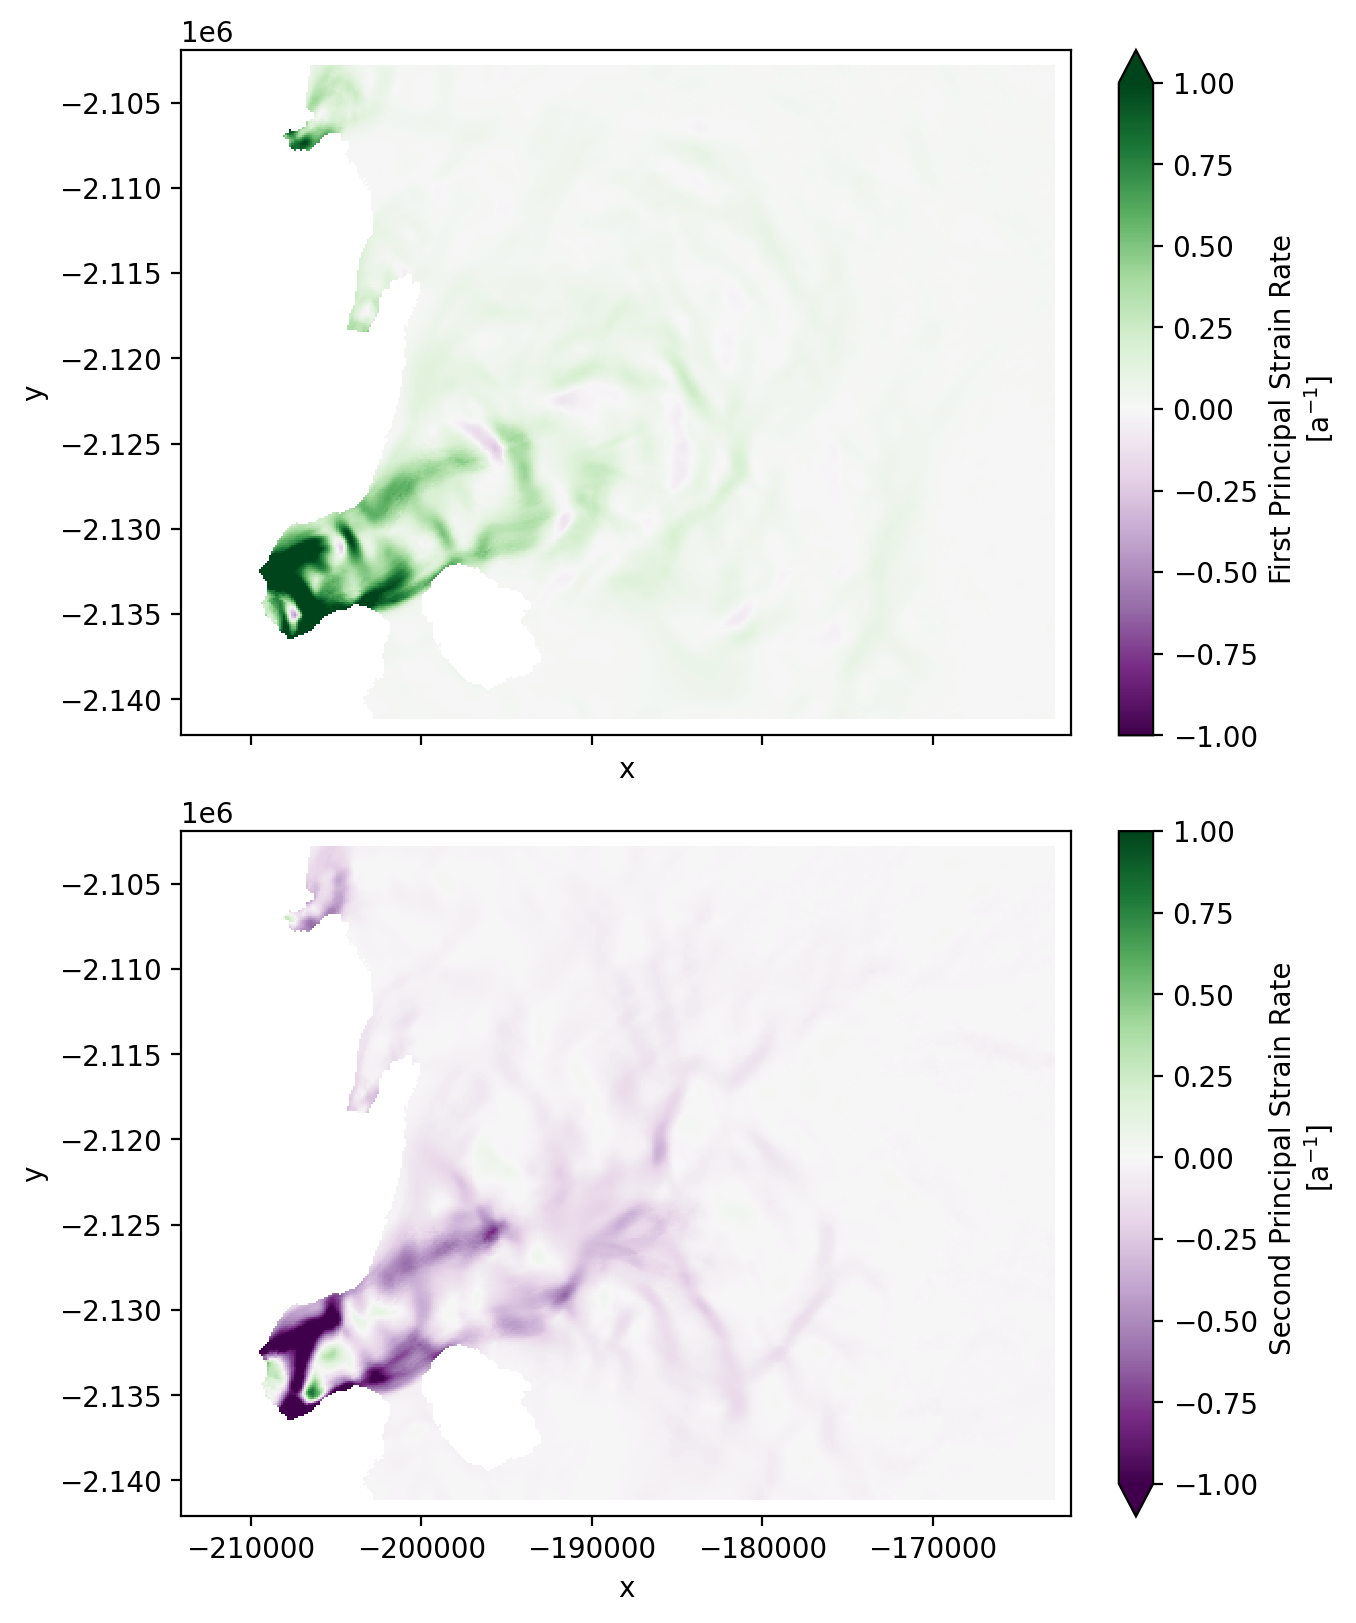

In [12]:
plt.close()
fig, axes = plt.subplots(nrows=2,sharex=True, sharey=True, layout='constrained', figsize=(6.5, 8))

vrange = 1.0 # a^-1

ax = axes[0]
principal.e_1.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax = axes[1]
principal.e_2.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

for ax in axes:
    ax.set_aspect('equal')
    ax.set_title(None)

plt.show()

### Other strain rates (longitudinal, transverse, shear, effective)

We can also calculate the longitudinal, transverse, and shear strain rates (here grouped together as 'rotated' strain rates) and the effective strain rates. To rotate the strain rates, we will also need the flow angle - this is calculated from the `vx` and `vy` fields using the helper function `flow_direction()`.

In [13]:
angle = st.flow_direction(vx, vy)

rotated = st.strain.rotated(strain.e_xx, strain.e_yy, strain.e_xy, angle)

effective = st.strain.effective(strain.e_xx, strain.e_yy, strain.e_xy)

The `rotated` output contains an `xarray.Dataset` containing longitudinal (`e_lon`), transverse (`e_trn`), and shear (`e_shr`) strain rates, whilst the `effective` output is a single `xarray.DataArray` containing effective strain rates only.

In [14]:
rotated

<xarray.Dataset> Size: 4MB
Dimensions:      (x: 435, y: 335)
Coordinates:
  * x            (x) float64 3kB -2.14e+05 -2.139e+05 ... -1.621e+05 -1.619e+05
  * y            (y) float64 3kB -2.102e+06 -2.102e+06 ... -2.142e+06 -2.142e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    e_lon        (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_trn        (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
    e_shr        (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan

In [15]:
effective

<xarray.DataArray 'e_E' (y: 335, x: 435)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(335, 435))
Coordinates:
  * y            (y) float64 3kB -2.102e+06 -2.102e+06 ... -2.142e+06 -2.142e+06
  * x            (x) float64 3kB -2.14e+05 -2.139e+05 ... -1.621e+05 -1.619e+05
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    long_name:  Effective Strain Rate
    units:      a$^{-1}$

Let's plot them:

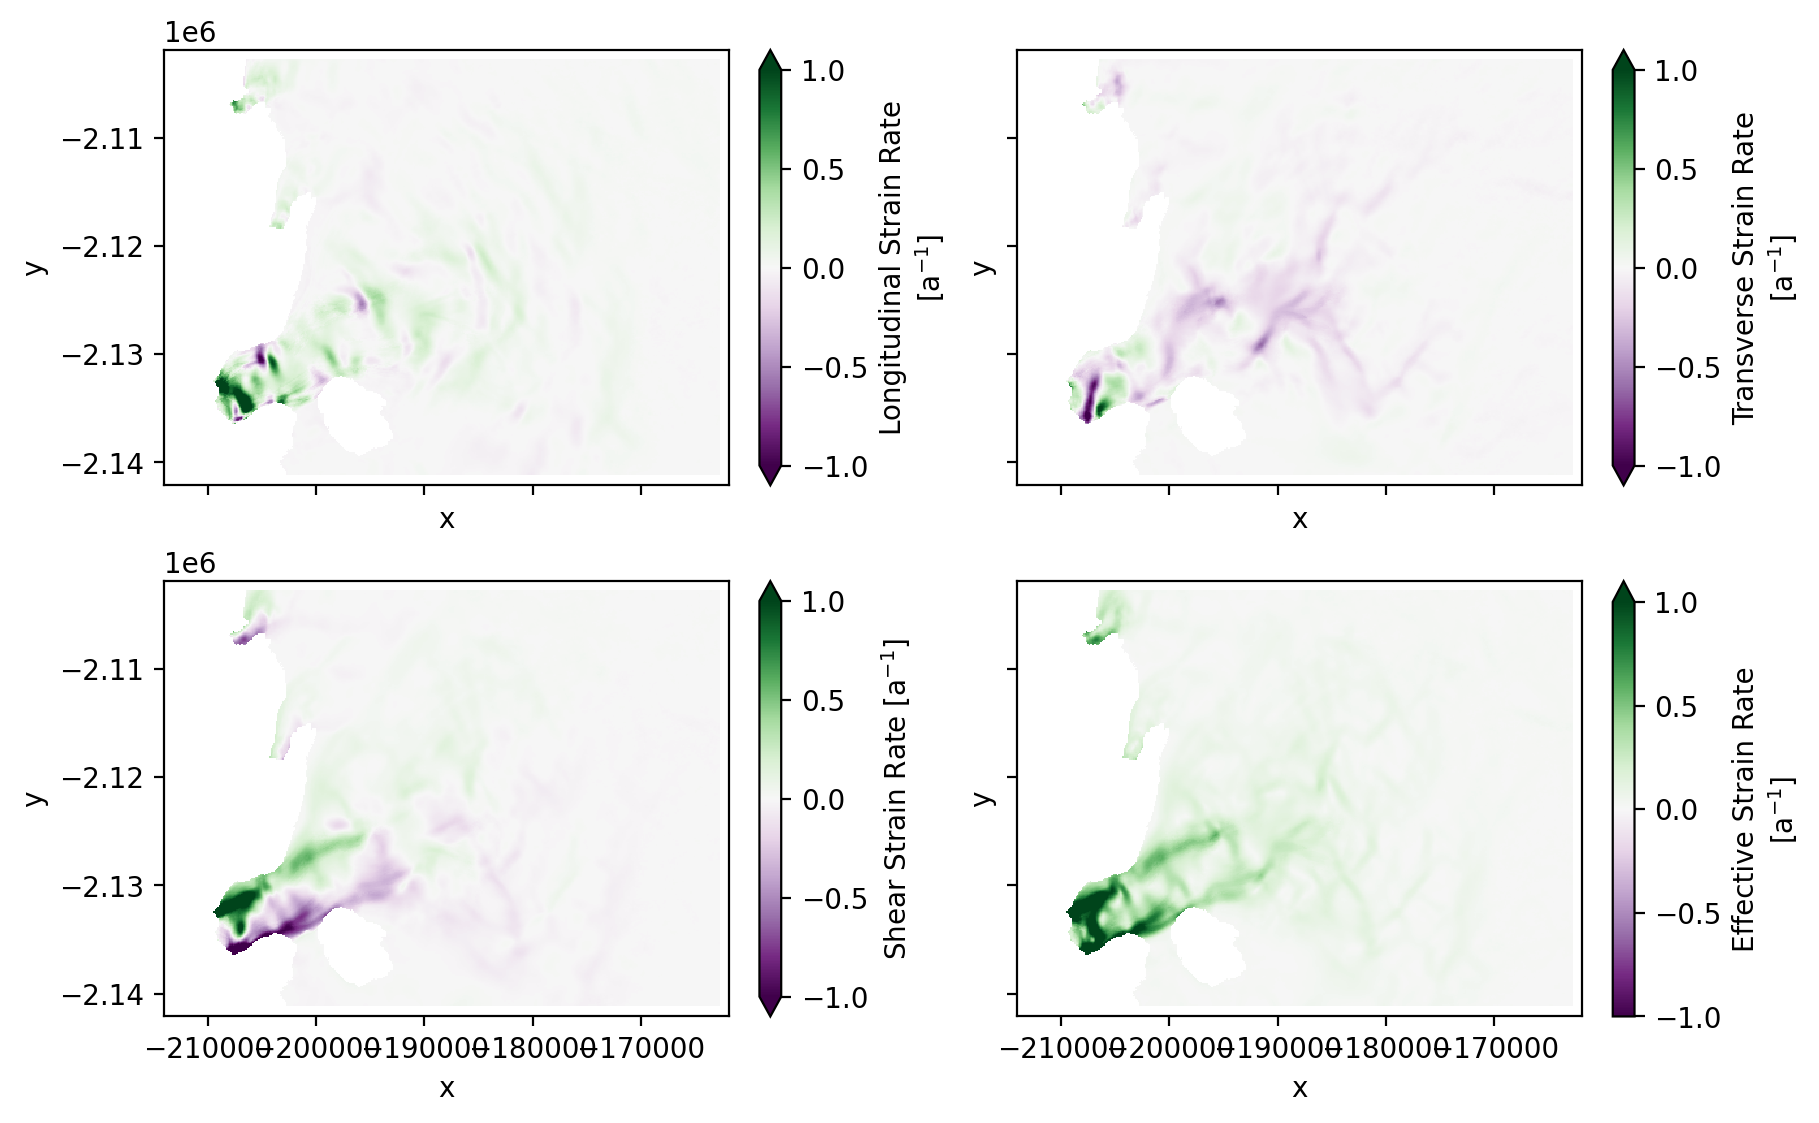

In [16]:
plt.close()
fig, axes = plt.subplots(nrows=2,ncols=2, sharex=True, sharey=True, layout='constrained', figsize=(9, 5.5))

vrange = 1.0 # a^-1

ax = axes[0,0]
rotated.e_lon.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax = axes[0, 1]
rotated.e_trn.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax = axes[1, 0]
rotated.e_shr.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax = axes[1, 1]
effective.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

for ax in axes.ravel():
    ax.set_aspect('equal')
    ax.set_title(None)

plt.show()

### Plotting quivers

One particularly cool way of plotting principal strain rates, following e.g. Colgan et al. (2016, https://doi.org/10.1002/2015RG000504) is by plotting the directions as 'strain crosses', aligned with the direction of flow. This is effectively just a quite complicated `matplotilb` `quiver()` plot, but it is wrapped into the `plot.strain_quiver()` function for your convenient. In the output, red is extending and blue is compressive strain. The quiver key likely requires manual positioning using the `keypos_x` and `keypos_y` variables. Other variables, available in the documentation, allow you to alter the scale and placement of the quivers.

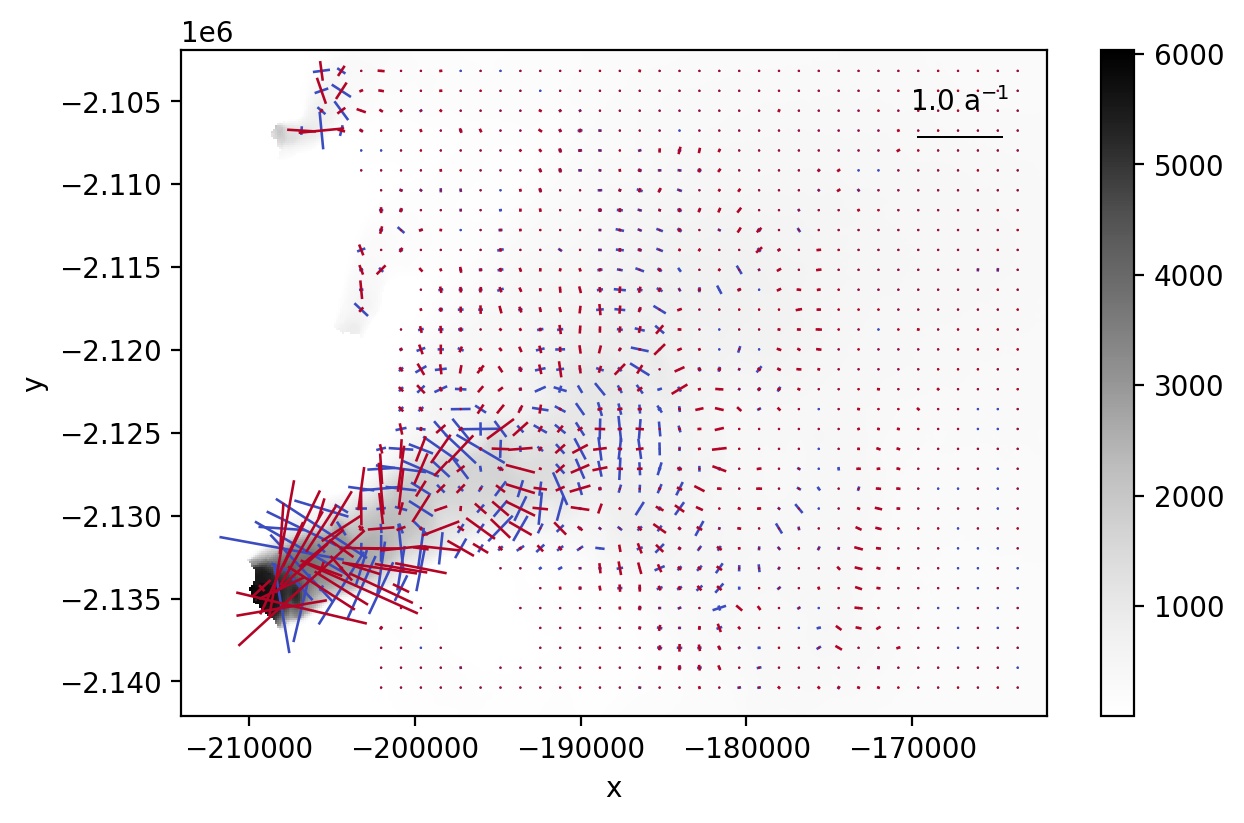

In [17]:

plt.close()
fig, ax = plt.subplots(layout='constrained', figsize=(6.5, 4))

vv.plot.imshow(ax=ax, cmap='Greys')
st.plot.strain_quiver(ax, principal, keypos_x = 0.9, keypos_y = 0.87, keycolor='black')

ax.set_aspect('equal')
ax.set_title(None)
plt.show()


## Stress

### Convert strain to stress

We can convert individual strain components to deviatoric stress (`stress.deviatoric()`) using Glen's flow law (Glen, 1955), as implemented by Wells-Moran _et al._ (2025, https://doi.org/10.1017/jog.2024.104), who collate a convenient set of 'default' variables that allow for implementations at $n=3$ and $n=4$. Note that here, temperature is set at a constant value. In 'proper' implementations, you probably want a variable temperature field (previous implementations have used e.g. the average ice surface temperature from RACMO/MAR data).

In [18]:
# Parameters
temperature = -5 # ˚C
n = 3

# ˚C > K
temperature += 273.15  # convert to K

# principal stresses
t_1 = st.stress.deviatoric(principal.e_1, effective, temperature=temperature, n=n, unit_output='kPa', long_name='First Principal Deviatoric Stress')
t_2 = st.stress.deviatoric(principal.e_2, effective, temperature=temperature, n=n, unit_output='kPa', long_name='Second Principal Deviatoric Stress')

We can also calculate the Cauchy stress of any strain rate direction (`stress.cauchy()`) by providing the first and second principal stresses. Note this is based on a simplified assumption that at the surface, $\sigma_3 = 0$ and hence the full relation between deviatoric and Cauchy stresses, via the isotropic pressure ($\tau_{ij} = \sigma_{ij} - p \delta_{ij}$) simplifies down to $\sigma_{ij} = \tau_{ij} + \tau_1 + \tau_2$ (see once again Wells-Moran _et al._ 2025, https://doi.org/10.1017/jog.2024.104, for a nice explanation of this).

In [19]:
# cauchy stress
s_1 = st.stress.cauchy(t_1, t_1, t_2, long_name='First Principal Cauchy Stress')
s_2 = st.stress.cauchy(t_2, t_1, t_2, long_name='Second Principal Cauchy Stress')


Let's plot these:

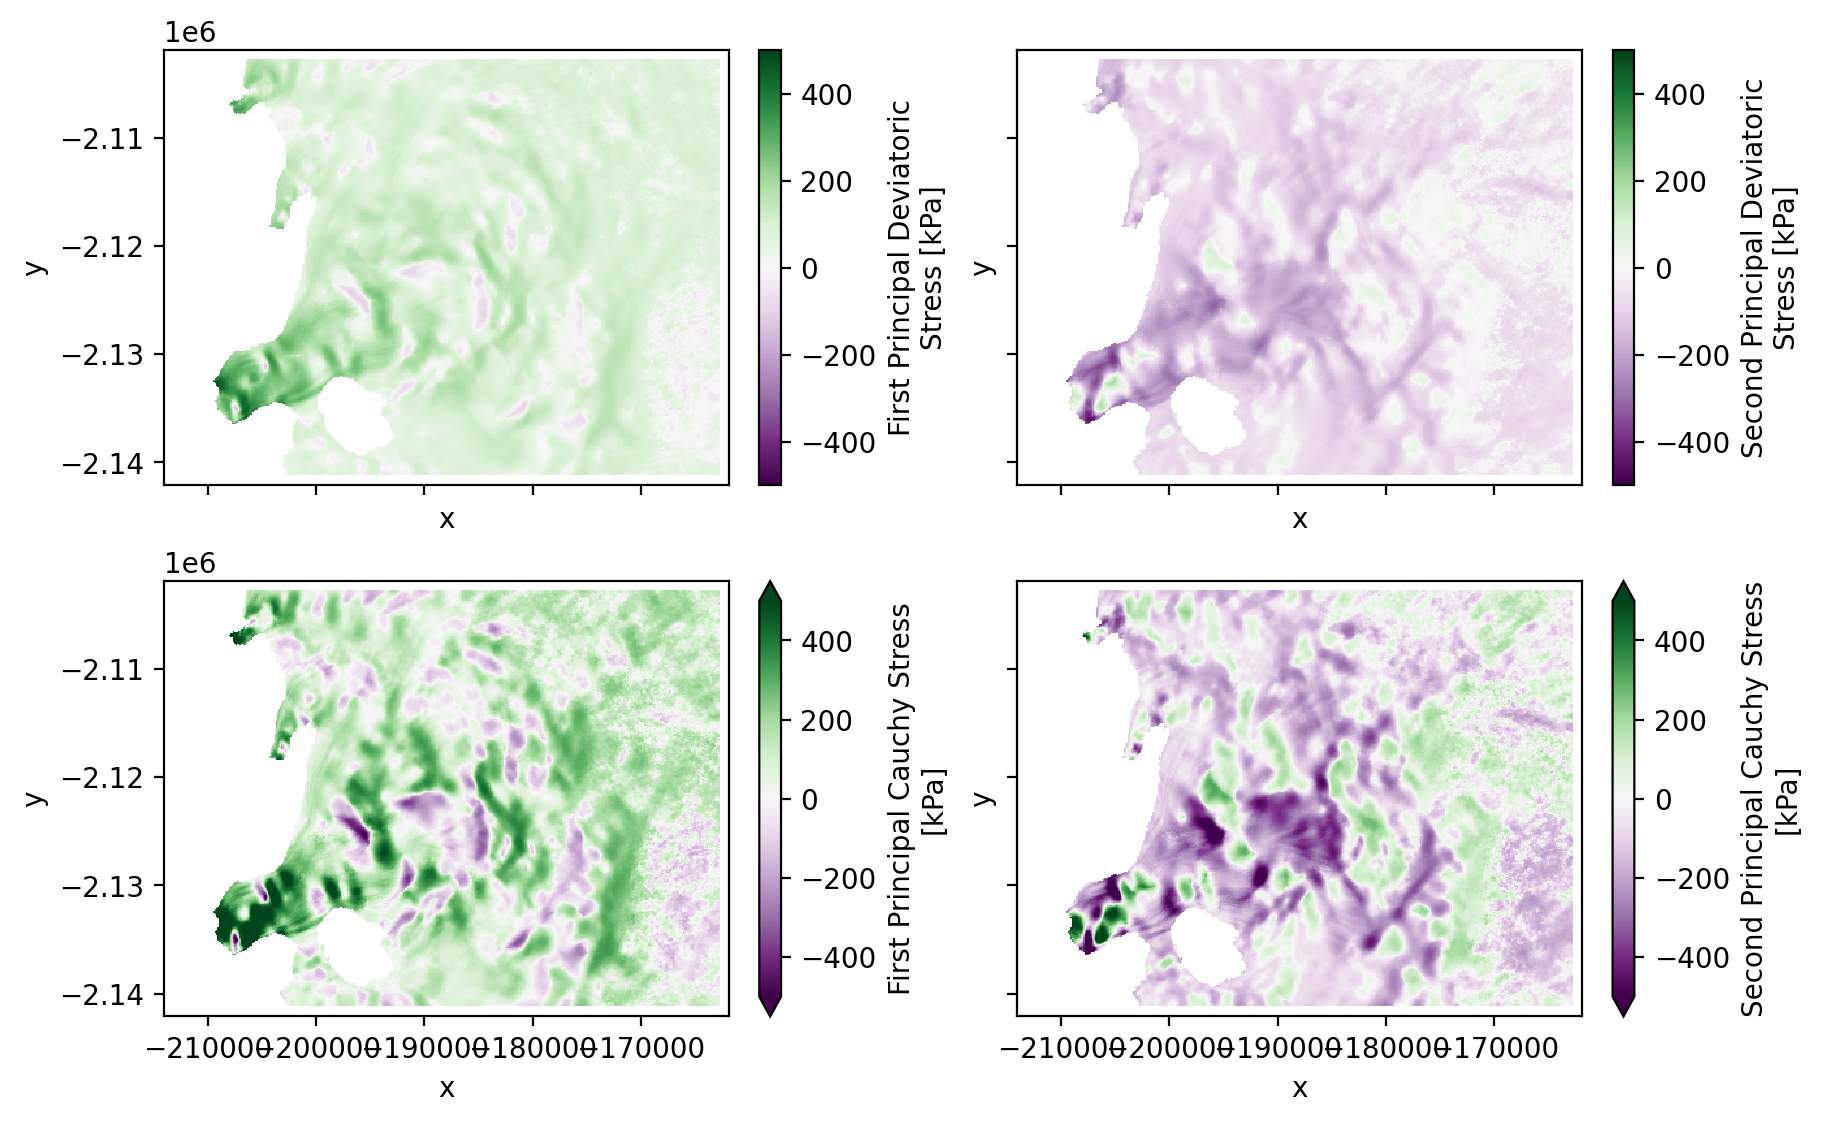

In [20]:
plt.close()
fig, axes = plt.subplots(nrows=2,ncols=2, sharex=True, sharey=True, layout='constrained', figsize=(9, 5.5))

vrange = 500 # a^-1

ax = axes[0,0]
t_1.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax = axes[0, 1]
t_2.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax = axes[1, 0]
s_1.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax = axes[1, 1]
s_2.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

for ax in axes.ravel():
    ax.set_aspect('equal')
    ax.set_title(None)

plt.show()

These functions can be applied to any strain rate:

In [21]:
# longitudinal stress
t_lon = st.stress.deviatoric(rotated.e_lon, effective, temperature=temperature, n=n, unit_output='kPa', long_name='Longitudinal Deviatoric Stress')
s_lon = st.stress.cauchy(t_lon, t_1, t_2, long_name='Longitudinal Cauchy Stress')

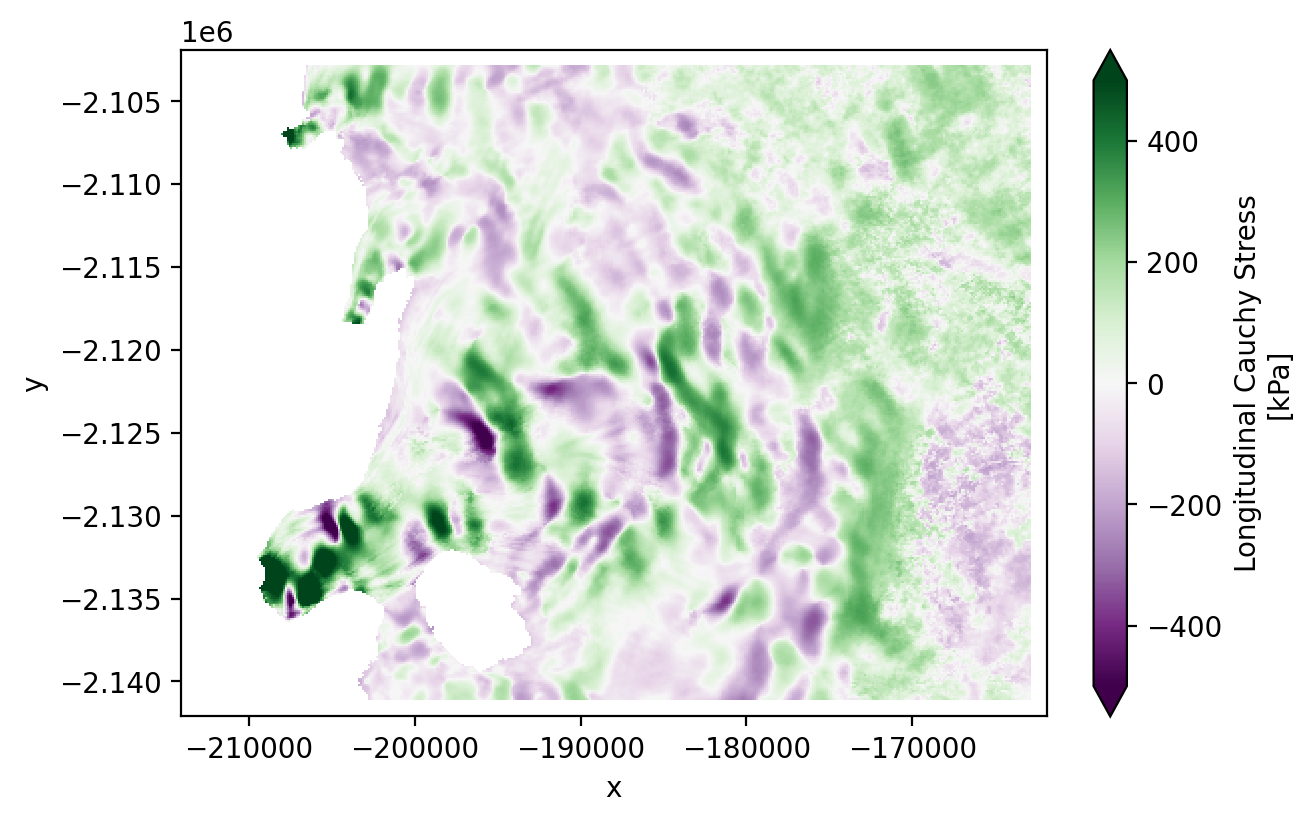

In [22]:
plt.close()
fig, ax = plt.subplots(layout='constrained', figsize=(6.5, 4))

vrange=500
s_lon.plot.imshow(ax=ax, vmin=-vrange, vmax=vrange, cmap='PRGn')

ax.set_aspect('equal')
ax.set_title(None)

plt.show()